In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_DIR = PROJECT_ROOT / "dataset"
CDL_RASTER_PATH = DATASET_DIR / "cdl_area1.tif"


# ── NOUVELLE structure : dossiers MCTNet_AreaX avec 36 .tif ──────────────────
AREA1_DIR = DATASET_DIR / "MCTNet_Area1"   # 36 fichiers .tif (timestamps)
AREA2_DIR = DATASET_DIR / "MCTNet_Area2"   # 36 fichiers .tif (timestamps)

# Bandes dans chaque .tif (ordre du papier MCTNet)
# Chaque .tif contient 10 bandes dans cet ordre :
S2_BANDS = ("B02", "B03", "B04", "B08", "B05", "B06", "B07", "B8A", "B11", "B12")
N_BANDS   = len(S2_BANDS)    # 10
N_TIMESTEPS = 36              # 36 images par zone

BATCH_SIZE    = 64
EPOCHS_DEFAULT = 150         
LEARNING_RATE = 1e-3
VAL_FRACTION  = 0.2
SEED          = 42

CDL_IGNORE_VALUES = (0,)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"Area1 TIFs   = {len(sorted(AREA1_DIR.glob('*.tif')))} fichiers")
print(f"Area2 TIFs   = {len(sorted(AREA2_DIR.glob('*.tif')))} fichiers")

PROJECT_ROOT = c:\Users\pc\Desktop\projet_rcr\Arkanssas
Area1 TIFs   = 36 fichiers
Area2 TIFs   = 36 fichiers


## Configuration (chemins CDL / Sentinel-2, bandes, entraînement)

## Lecture Sentinel-2 L2A 

In [4]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling as WarpResampling
from typing import List, Tuple


def load_tif_list(area_dir: Path) -> List[Path]:
    """Retourne les 36 .tif triés par nom (= ordre temporel)."""
    tifs = sorted(area_dir.glob("*.tif"))
    if len(tifs) == 0:
        raise FileNotFoundError(f"Aucun .tif dans {area_dir}")
    return tifs


def read_tif_bands(tif_path: Path, n_bands: int = 10) -> np.ndarray:
    """
    Lit un .tif multi-bandes → array (H, W, n_bands) float32.
    Les pixels nodata sont mis à NaN.
    """
    with rasterio.open(tif_path) as src:
        # src.count = nombre de bandes dans le fichier
        bands_to_read = min(n_bands, src.count)
        arr = src.read(list(range(1, bands_to_read + 1))).astype(np.float32)  # (B, H, W)
        nodata = src.nodata
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr)
        arr = arr.transpose(1, 2, 0)  # → (H, W, B)
    return arr


def get_tif_transform(tif_path: Path):
    """Retourne (transform, crs, height, width) du premier .tif."""
    with rasterio.open(tif_path) as src:
        return src.transform, src.crs, src.height, src.width


def load_cdl_labels(path: Path):
    """Charge le raster CDL → array (H, W) int32 + profile."""
    with rasterio.open(path) as src:
        y = src.read(1).astype(np.int32)
        profile = src.profile
    return y, profile


def reproject_cdl_to_tif(cdl_path: Path, ref_tif_path: Path) -> np.ndarray:
    """
    Reprojette / rééchantillonne le CDL sur la grille du premier .tif.
    Indispensable si CDL et S2 n'ont pas la même résolution / CRS.
    """
    with rasterio.open(ref_tif_path) as ref:
        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_height = ref.height
        ref_width = ref.width

    with rasterio.open(cdl_path) as src:
        dst_arr = np.empty((ref_height, ref_width), dtype=np.int32)
        reproject(
            source=rasterio.band(src, 1),
            destination=dst_arr,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=WarpResampling.nearest,  # nearest pour labels entiers !
        )
    return dst_arr


def scale_to_reflectance(x: np.ndarray) -> np.ndarray:
    """DN L2A (0-10000) → réflectance (0-1). Ignore les NaN."""
    x = np.asarray(x, dtype=np.float32)
    return np.where(x > 1.5, x / 10000.0, np.clip(x, 0.0, 1.0))


def add_spectral_indices_pixel(X: np.ndarray) -> np.ndarray:
    """
    Ajoute NDVI et NDWI à X de forme (N, T, C).
    Ordre des bandes = S2_BANDS : B02=0, B03=1, B04=2, B08=3
    """
    eps = 1e-6
    X_ref = scale_to_reflectance(X)
    B03 = X_ref[:, :, 1]  # Green
    B04 = X_ref[:, :, 2]  # Red
    B08 = X_ref[:, :, 3]  # NIR
    ndvi = (B08 - B04) / (B08 + B04 + eps)
    ndwi = (B03 - B08) / (B03 + B08 + eps)
    X_out = np.concatenate(
        [X_ref, ndvi[..., None], ndwi[..., None]], axis=-1
    ).astype(np.float32)
    return X_out

## Dataset : CDL, pile temporelle, échantillons synthétiques

In [5]:
from sklearn.model_selection import train_test_split

def remap_labels(raw: np.ndarray, ignore=(0,)):
    ignore_set = set(int(x) for x in ignore)
    codes = sorted(int(c) for c in np.unique(raw) if c not in ignore_set and c >= 0)
    code_to_idx = {c: i for i, c in enumerate(codes)}
    out = np.full_like(raw, -1, dtype=np.int32)
    for c, i in code_to_idx.items():
        out[raw == c] = i
    rev = {i: c for c, i in code_to_idx.items()}
    return out, rev


def select_pixel_indices_stratified(
    labels_hw: np.ndarray,
    max_samples: int,
    min_per_class: int = 2000,
    seed: int = 42,
):
    """
    Garantit min_per_class échantillons pour chaque classe,
    puis complète avec Others jusqu'à max_samples.
    """
    import numpy as np
    rng = np.random.default_rng(seed)
    flat_y = labels_hw.reshape(-1)
    valid = flat_y >= 0
    classes = np.unique(flat_y[valid])
    h, w = labels_hw.shape

    parts = []
    for cl in classes:
        pos = np.flatnonzero(valid & (flat_y == cl))
        if pos.size == 0:
            continue
        # Prend le max disponible, au moins min_per_class si possible
        n_take = min(min_per_class, pos.size)
        parts.append(rng.choice(pos, size=n_take, replace=True))  # replace=True si insuffisant

    idx = np.concatenate(parts)
    if idx.size > max_samples:
        idx = rng.choice(idx, size=max_samples, replace=False)

    rows = (idx // w).astype(np.int32)
    cols = (idx % w).astype(np.int32)
    y = flat_y[idx].astype(np.int32)
    return rows, cols, y


def build_pixel_dataset_from_tifs(
    area_dir: Path,
    cdl_labels_hw: np.ndarray,       # CDL déjà reprojeté sur la grille .tif
    max_samples: int = 10_000,
    seed: int = 42,
    n_bands: int = 10,
    add_indices: bool = True,
    stratified: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Lit les 36 .tif de area_dir, extrait des pixels échantillonnés.

    Retourne :
        X            : (N, T=36, C)  float32  — valeurs 0 pour données manquantes
        y            : (N,)          int32
        mask_valid   : (N, T)        bool     — True si timestamp non-manquant
    """
    tif_paths = load_tif_list(area_dir)
    T = len(tif_paths)  # doit être 36

    # 1) Choisir les pixels
    if stratified:
        rows, cols, y = select_pixel_indices_stratified(
            cdl_labels_hw, max_samples=max_samples, seed=seed
        )
    else:
        rng = np.random.default_rng(seed)
        flat_y = cdl_labels_hw.reshape(-1)
        idx = np.flatnonzero(flat_y >= 0)
        if idx.size > max_samples:
            idx = rng.choice(idx, size=max_samples, replace=False)
        h, w = cdl_labels_hw.shape
        rows = (idx // w).astype(np.int32)
        cols = (idx % w).astype(np.int32)
        y = flat_y[idx].astype(np.int32)

    N = rows.size
    X = np.zeros((N, T, n_bands), dtype=np.float32)  

    # 2) Lire chaque timestamp
    for ti, tif_path in enumerate(tif_paths):
        arr_hwb = read_tif_bands(tif_path, n_bands=n_bands)  # (H, W, B)
        pixel_vals = arr_hwb[rows, cols, :]                  # (N, B)
        # Remplace NaN par 0 
        pixel_vals = np.where(np.isnan(pixel_vals), 0.0, pixel_vals)
        X[:, ti, :] = pixel_vals

    # 3) Masque temporel : True si au moins une bande non-nulle
    mask_valid = np.any(X != 0.0, axis=-1)  # (N, T)

    # 4) Option indices spectraux
    if add_indices:
        X = add_spectral_indices_pixel(X)  # (N, T, 12)

    return X, y, mask_valid

In [6]:
import sys
print(sys.executable)
from pathlib import Path
print(Path.cwd())

c:\Users\pc\Desktop\projet_rcr\Arkanssas\.venv\Scripts\python.exe
c:\Users\pc\Desktop\projet_rcr\Arkanssas\notebooks


## Modèle : MCTNet (CNN–Transformer)


In [7]:
# Baseline MLP retiré — classification avec MCTNet uniquement (`build_mctnet`).
import tensorflow as tf


## 1) Données réelles — CDL + `dataset/safes.txt`

In [8]:
# ═══════════════════════════════════════════════════════
#  CHARGEMENT DES DONNÉES RÉELLES — MCTNet_Area1 + Area2
# ═══════════════════════════════════════════════════════

MAX_SAMPLES = 50_000
SAMPLES_PER_CLASS = 2000
ADD_SPECTRAL_INDICES = True
USE_STRATIFIED_SAMPLING = True

USE_PAPER_5_CLASSES = True
PAPER_LABELS = ['Corn', 'Cotton', 'Soybean', 'Rice', 'Others']

# Référence tifs Area1/Area2
ref_tif1 = load_tif_list(AREA1_DIR)[0]
ref_tif2 = load_tif_list(AREA2_DIR)[0]

# CDL séparés par zone (important !)
CDL_RASTER_PATH_AREA1 = DATASET_DIR / "cdl_area1.tif"
CDL_RASTER_PATH_AREA2 = DATASET_DIR / "cdl_area2.tif"

y_raw_reproj1 = reproject_cdl_to_tif(CDL_RASTER_PATH_AREA1, ref_tif1)
y_raw_reproj2 = reproject_cdl_to_tif(CDL_RASTER_PATH_AREA2, ref_tif2)

def map_cdl_to_5classes(cdl_arr: np.ndarray) -> np.ndarray:
    out = np.full_like(cdl_arr, -1, dtype=np.int32)
    out[cdl_arr == 1] = 0
    out[cdl_arr == 2] = 1
    out[cdl_arr == 5] = 2
    out[cdl_arr == 3] = 3
    # Inclure aussi 61 (tu l’avais exclu via range(1,61))
    CROP_CODES = set(range(1, 62))
    MAIN_CODES = {1, 2, 3, 5}
    for code in CROP_CODES - MAIN_CODES:
        out[cdl_arr == code] = 4
    return out

y_5classes_area1 = map_cdl_to_5classes(y_raw_reproj1)
y_5classes_area2 = map_cdl_to_5classes(y_raw_reproj2)

# Debug rapide
print("Area1 valid classes:", np.unique(y_5classes_area1[y_5classes_area1 >= 0]))
print("Area2 valid classes:", np.unique(y_5classes_area2[y_5classes_area2 >= 0]))

MAX_SAMPLES = SAMPLES_PER_CLASS * 5  # 10_000 par zone

X_area1, y_area1, mask_area1 = build_pixel_dataset_from_tifs(
    AREA1_DIR, y_5classes_area1,
    max_samples=MAX_SAMPLES, seed=SEED,
    n_bands=N_BANDS, add_indices=ADD_SPECTRAL_INDICES, stratified=True
)

X_area2, y_area2, mask_area2 = build_pixel_dataset_from_tifs(
    AREA2_DIR, y_5classes_area2,
    max_samples=MAX_SAMPLES, seed=SEED,
    n_bands=N_BANDS, add_indices=ADD_SPECTRAL_INDICES, stratified=True
)

X = np.concatenate([X_area1, X_area2], axis=0)
y = np.concatenate([y_area1, y_area2], axis=0)
mask_time = np.concatenate([mask_area1, mask_area2], axis=0)

# Zone id: 0=Area1, 1=Area2 (utile pour un split plus robuste)
zone_id = np.concatenate([
    np.zeros(len(y_area1), dtype=np.int32),
    np.ones(len(y_area2), dtype=np.int32),
], axis=0)

# Filtrage qualité temporelle : retire les séries trop incomplètes
min_valid_timesteps = 8
valid_steps = mask_time.sum(axis=1)
keep = valid_steps >= min_valid_timesteps

print(f"\nFiltrage qualité temporelle : >= {min_valid_timesteps} timesteps valides")
print(f"Samples conservés : {int(np.sum(keep))}/{len(keep)}")

X = X[keep]
y = y[keep]
mask_time = mask_time[keep]
zone_id = zone_id[keep]

n_classes = 5

# Split stratifié classe + zone pour réduire le domain shift Area1/Area2
stratify_key = np.array([f"{int(c)}_{int(z)}" for c, z in zip(y, zone_id)])

X_train, X_val, y_train, y_val, mask_train, mask_val, zone_train, zone_val = train_test_split(
    X, y, mask_time, zone_id,
    test_size=VAL_FRACTION,
    random_state=SEED,
    stratify=stratify_key
)

# === Affichage complet des données train/val ===
print("=== Split train/val (Area1 + Area2) ===")
print("X_train:", X_train.shape, "| y_train:", np.asarray(y_train).shape, "| mask_train:", np.asarray(mask_train).shape)
print("X_val  :", X_val.shape, "| y_val  :", np.asarray(y_val).shape, "| mask_val  :", np.asarray(mask_val).shape)
print("zone_train:", np.asarray(zone_train).shape, "| zone_val:", np.asarray(zone_val).shape)

# Distribution des classes
y_train_flat = np.asarray(y_train).reshape(-1)
y_val_flat = np.asarray(y_val).reshape(-1)

if np.any(y_train_flat < 0) or np.any(y_val_flat < 0):
    print("[WARN] Présence de labels < 0 dans train/val.")

classes = list(range(int(n_classes)))

def _dist(y_arr, name):
    total = len(y_arr)
    print(f"\nDistribution {name} (total={total}):")
    for c in classes:
        cnt = int(np.sum(y_arr == c))
        frac = cnt / total if total else 0.0
        label_name = PAPER_LABELS[c] if "PAPER_LABELS" in globals() and len(PAPER_LABELS) > c else str(c)
        print(f"  - {c} ({label_name}): {cnt} ({frac*100:.2f}%)")

_dist(y_train_flat, "y_train")
_dist(y_val_flat, "y_val")

# Répartition des zones train/val
print("\nRépartition zones:")
print("  train -> Area1:", int(np.sum(zone_train == 0)), "| Area2:", int(np.sum(zone_train == 1)))
print("  val   -> Area1:", int(np.sum(zone_val == 0)), "| Area2:", int(np.sum(zone_val == 1)))

# Récap masque temporel : nb de timesteps valides par sample
mask_train_arr = np.asarray(mask_train)
mask_val_arr = np.asarray(mask_val)
vt_train = mask_train_arr.sum(axis=1)
vt_val = mask_val_arr.sum(axis=1)

print("\nMask temporel (timesteps valides par sample):")
print(
    "  train: mean=", float(vt_train.mean()), "min=", int(vt_train.min()), "max=", int(vt_train.max()),
    "| val: mean=", float(vt_val.mean()), "min=", int(vt_val.min()), "max=", int(vt_val.max()),
)

# Normalisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
N_tr, T, C = X_train.shape
X_train = scaler.fit_transform(X_train.reshape(-1, C)).reshape(N_tr, T, C).astype(np.float32)

N_val = X_val.shape[0]
X_val = scaler.transform(X_val.reshape(-1, C)).reshape(N_val, T, C).astype(np.float32)

print(f"\nDonnées prêtes : Train={X_train.shape}, Val={X_val.shape}")

Area1 valid classes: [0 1 2 3 4]
Area2 valid classes: [0 1 2 3 4]

Filtrage qualité temporelle : >= 8 timesteps valides
Samples conservés : 19057/20000
=== Split train/val (Area1 + Area2) ===
X_train: (15245, 36, 12) | y_train: (15245,) | mask_train: (15245, 36)
X_val  : (3812, 36, 12) | y_val  : (3812,) | mask_val  : (3812, 36)
zone_train: (15245,) | zone_val: (3812,)

Distribution y_train (total=15245):
  - 0 (Corn): 3059 (20.07%)
  - 1 (Cotton): 2938 (19.27%)
  - 2 (Soybean): 3090 (20.27%)
  - 3 (Rice): 3138 (20.58%)
  - 4 (Others): 3020 (19.81%)

Distribution y_val (total=3812):
  - 0 (Corn): 765 (20.07%)
  - 1 (Cotton): 735 (19.28%)
  - 2 (Soybean): 773 (20.28%)
  - 3 (Rice): 785 (20.59%)
  - 4 (Others): 754 (19.78%)

Répartition zones:
  train -> Area1: 7628 | Area2: 7617
  val   -> Area1: 1908 | Area2: 1904

Mask temporel (timesteps valides par sample):
  train: mean= 28.247490980649392 min= 21 max= 35 | val: mean= 28.247639034627493 min= 22 max= 35

Données prêtes : Train=(1524

In [9]:
# Mis à jour automatiquement depuis les données chargées
N_TIMESTEPS = X_train.shape[1]   
N_CHANNELS  = X_train.shape[2]   
                                 
N_CLASSES   = n_classes          

print(f"Modèle MCTNet : T={N_TIMESTEPS}, C={N_CHANNELS}, classes={N_CLASSES}")

Modèle MCTNet : T=36, C=12, classes=5


## 2) Entraînement — MCTNet


In [10]:
EPOCHS = 50
BATCH_SIZE_RUN = BATCH_SIZE
LR = LEARNING_RATE

CHECKPOINT_DIR = PROJECT_ROOT / ".checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)
MCTNET_CKPT_PATH = CHECKPOINT_DIR / "mctnet_best.weights.h5"


In [11]:
import sys, importlib
sys.path.append(str(PROJECT_ROOT))
import mctnet_model
importlib.reload(mctnet_model)
from mctnet_model import build_mctnet

Model: "mctnet_masked_cnn_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ x_s2_clim           │ (None, 36, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_valid_mask     │ (None, 36)        │          0 │ x_s2_clim[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ replace_non_finite… │ (None, 36, 12)    │          0 │ x_s2_clim[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_valid_mask_bo… │ (None, 36)        │          0 │ time_valid_mask[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv1D)  │ (None, 36, 64)    │        768 │ replace_non_fini… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ensure_one_valid    │ (None, 36)        │          0 │ time_valid_mask_… │
│ (EnsureOneValidTim… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 36, 64)    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_valid_mask_fi… │ (None, 36)        │          0 │ ensure_one_valid… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 36, 64)    │          0 │ stem_bn[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention_mask │ (None, 36, 36)    │          0 │ time_valid_mask_… │
│ (BuildSelfAttentio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_alpe (ALPE)  │ (None, 36, 64)    │     12,355 │ time_valid_mask_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_fusion_0         │ (None, 36, 64)    │     67,014 │ stem_relu[0][0],  │
│ (CTFusion)          │                   │            │ time_valid_mask_… │
│                     │                   │            │ self_attention_m… │
│                     │                   │            │ shared_alpe[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_fusion_1         │ (None, 36, 64)    │     67,014 │ ct_fusion_0[0][0… │
│ (CTFusion)          │                   │            │ time_valid_mask_… │
│                     │                   │            │ self_attention_m… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_fusion_2         │ (None, 36, 64)    │     67,014 │ ct_fusion_1[0][0… │
│ (CTFusion)          │                   │            │ time_valid_mask_… │
│                     │                   │            │ self_attention_m… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_gap          │ (None, 64)        │          0 │ ct_fusion_2[0][0… │
│ (MaskedGlobalAvera… │                   │            │ time_valid_mask_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_drop (Dropout) │ (None, 64)        │          0 │ masked_gap[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 214,746 (838.85 KB)

 Trainable params: 213,850 (835.35 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/40
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4893 - loss: 0.4168 - macro_f1: 0.4876
Epoch 1: val_macro_f1 improved from None to 0.46845, saving model to c:\Users\pc\Desktop\projet_rcr\Arkanssas\.checkpoints\mctnet_best_v2.weights.h5

Epoch 1: finished saving model to c:\Users\pc\Desktop\projet_rcr\Arkanssas\.checkpoints\mctnet_best_v2.weights.h5
246/246 ━━━━━━━━━━━━━━━━━━━━ 45s 74ms/step - accuracy: 0.5811 - loss: 0.3565 - macro_f1: 0.5798 - val_accuracy: 0.5008 - val_loss: 0.4080 - val_macro_f1: 0.4684 - learning_rate: 7.0000e-04
Epoch 2/40
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7220 - loss: 0.2717 - macro_f1: 0.7220
Epoch 2: val_macro_f1 improved from 0.46845 to 0.73353, saving model to c:\Users\pc\Desktop\projet_rcr\Arkanssas\.checkpoints\mctnet_best_v2.weights.h5

Epoch 2: finished saving model to c:\Users\pc\Desktop\projet_rcr\Arkanssas\.checkpoints\mctnet_best_v2.weights.h5
246/246 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.7455 - loss

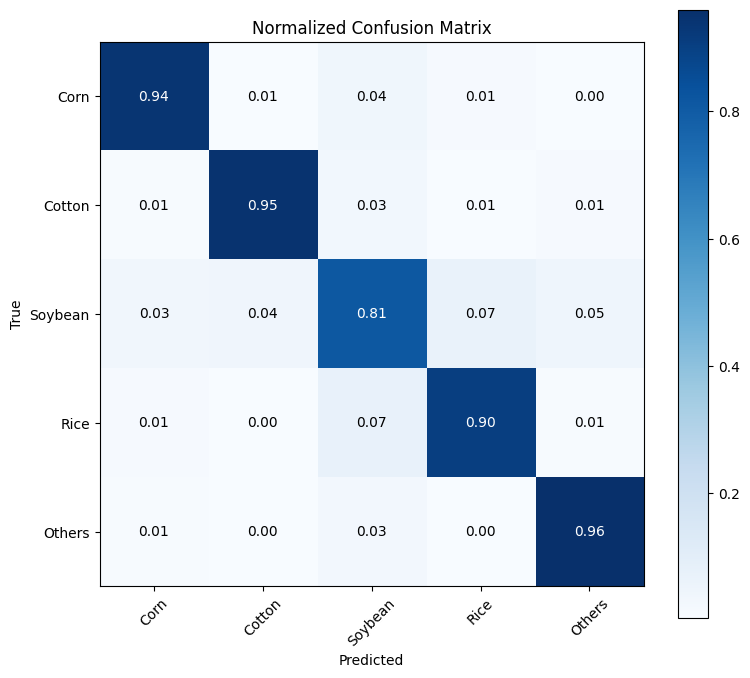

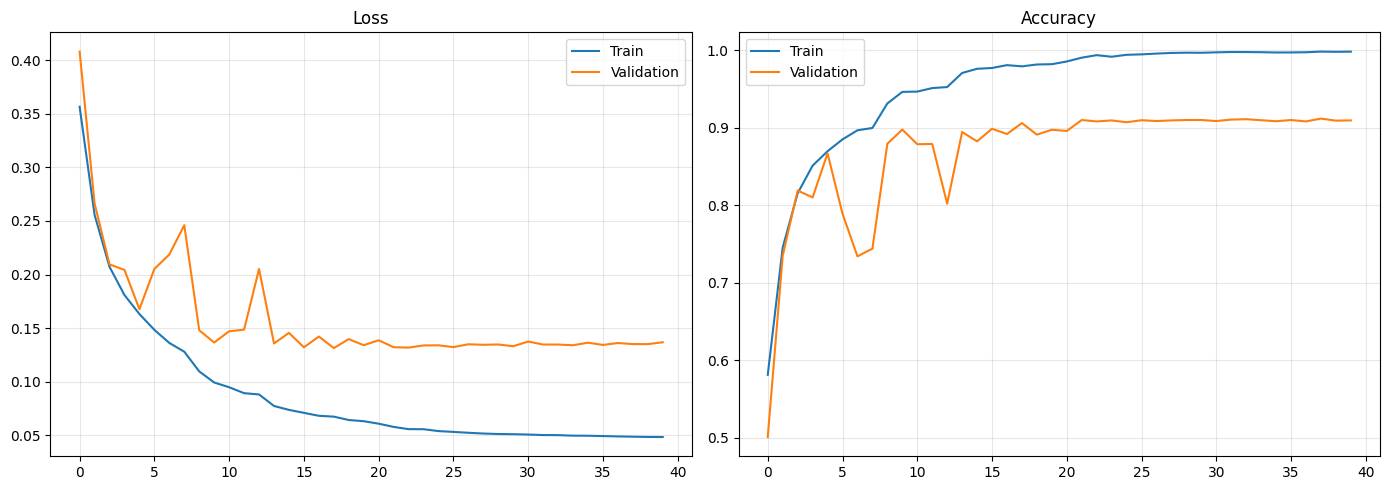

In [12]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
    f1_score,
    confusion_matrix,
)

from training_utils import (
    oversample_balanced,
    make_augment_tf_wrapper,
    SparseCategoricalFocalLoss,
    MacroF1Score,
    CosineAnnealingLearningRate,
)

# =========================================================
# 1. PREPARATION DATASET
# =========================================================

X_train_b, y_train_b = oversample_balanced(
    X_train,
    y_train,
    seed=SEED
)

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_b, y_train_b))
    .shuffle(len(X_train_b))
    .map(
        make_augment_tf_wrapper(
            p=0.25,
            seed=SEED
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# =========================================================
# 2. MODEL
# =========================================================

ct = build_mctnet(
    n_timesteps=X_train.shape[1],
    n_channels=X_train.shape[2],
    n_classes=5,

    d_model=64,
    num_heads=4,
    ff_dim=128,
    n_stage=3,

    dropout=0.35,
    l2=1e-4
)

ct.summary()

# =========================================================
# 3. COMPILATION
# =========================================================

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=7e-4,
    weight_decay=5e-4,
    clipnorm=1.0,
)

ct.compile(
    optimizer=optimizer,
    loss=SparseCategoricalFocalLoss(
        gamma=1.5,
        alpha=0.35
    ),
    metrics=[
        "accuracy",
        MacroF1Score(n_classes=5, name="macro_f1")
    ]
)

# =========================================================
# 4. CALLBACKS
# =========================================================

checkpoint_path = (
    PROJECT_ROOT /
    ".checkpoints" /
    "mctnet_best_v2.weights.h5"
)

callbacks_mctnet = [

    # Save best model
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),

    # Early stopping
    tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),

    # Reduce LR if plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_macro_f1",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),

]

# =========================================================
# 5. TRAINING
# =========================================================

history = ct.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks_mctnet,
    verbose=1
)

# =========================================================
# 6. LOAD BEST WEIGHTS
# =========================================================

ct.load_weights(str(checkpoint_path))

print("\n--- TRAINING FINISHED ---")

# =========================================================
# 7. PREDICTIONS
# =========================================================

_class_names = [
    "Corn",
    "Cotton",
    "Soybean",
    "Rice",
    "Others"
]

y_true = np.asarray(y_val).reshape(-1)

y_prob = ct.predict(
    X_val,
    batch_size=BATCH_SIZE,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

# =========================================================
# 8. CLASSIFICATION REPORT
# =========================================================

print("\n=== MCTNet Validation ===\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=_class_names,
        digits=4
    )
)

# =========================================================
# 9. METRICS
# =========================================================

oa = accuracy_score(y_true, y_pred)

kappa = cohen_kappa_score(y_true, y_pred)

f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro"
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("\n--- GLOBAL METRICS ---")
print(f"OA            : {oa:.4f}")
print(f"Kappa         : {kappa:.4f}")
print(f"F1 Macro      : {f1_macro:.4f}")
print(f"F1 Weighted   : {f1_weighted:.4f}")

# =========================================================
# 10. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred)

cm = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(_class_names)))
ax.set_yticks(np.arange(len(_class_names)))

ax.set_xticklabels(_class_names, rotation=45)
ax.set_yticklabels(_class_names)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Normalized Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        value = cm[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value > 0.5 else "black"
        )

fig.colorbar(im)

plt.tight_layout()
plt.show()

# =========================================================
# 11. LEARNING CURVES
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LOSS
axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ACCURACY
axes[1].plot(history.history["accuracy"], label="Train")
axes[1].plot(history.history["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

 ## 4) NDVI (Arkansas) + cartes de classification

[info] `y_pred_ct` absent -> calcul des prédictions depuis `ct`...
[ok] y_pred_ct généré: (3812,)


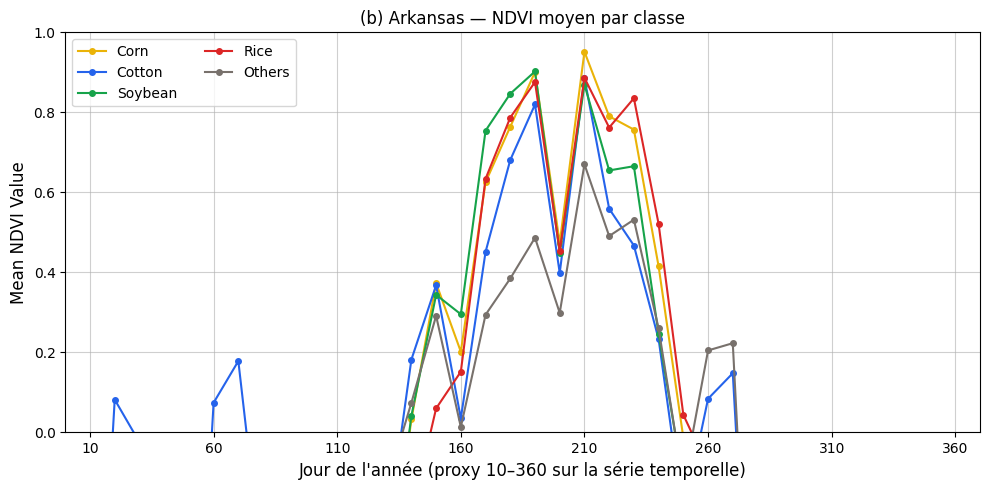

Figure NDVI sauvegardée : c:\Users\pc\Desktop\projet_rcr\Arkanssas\NDVI_timeseries_Arkansas.png


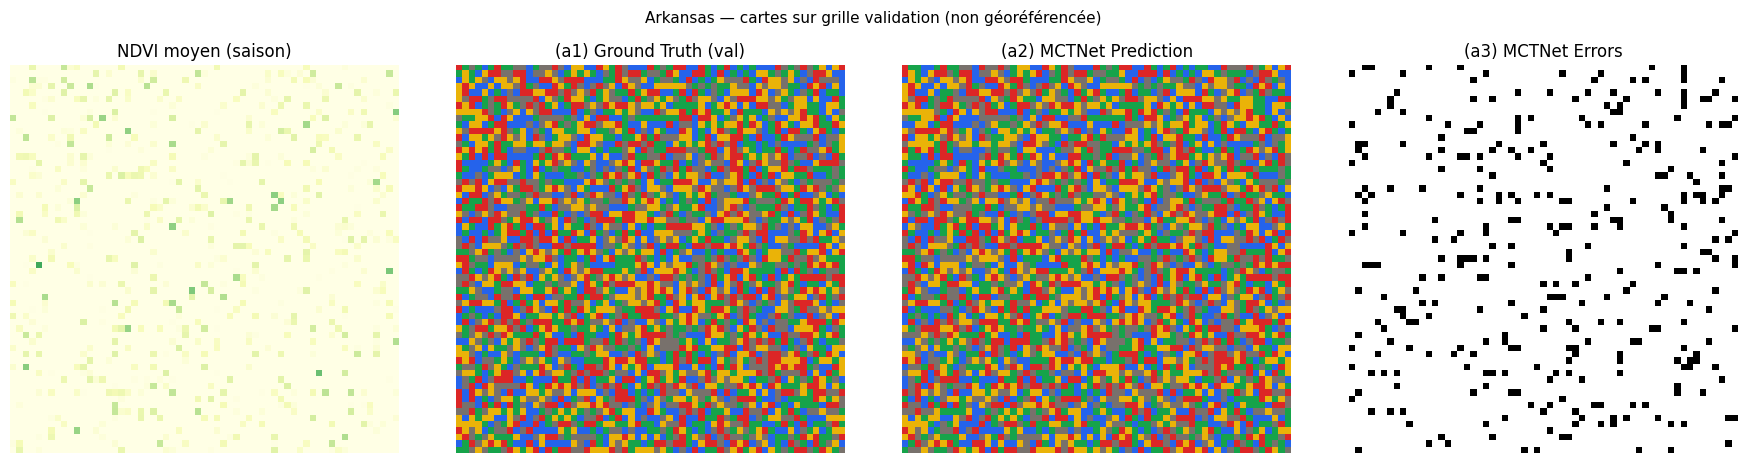

Figure cartes sauvegardée : c:\Users\pc\Desktop\projet_rcr\Arkanssas\Classification_Maps_Arkansas.png


In [13]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

_REQUIRED = (
    "PROJECT_ROOT",
    "X_train",
    "X_val",
    "y_train",
    "y_val",
    "n_classes",
)
_missing = [n for n in _REQUIRED if n not in globals()]
if _missing:
    raise RuntimeError(
        "Variables absentes du noyau : "
        + ", ".join(_missing)
        + ". Exécute d'abord « Run All Above » sur cette cellule, ou rejoue au minimum : "
        "PROJECT_ROOT → données (sections 1 ou 2) → entraînement MCTNet. "
        "Cette cellule ne peut pas être exécutée en premier (kernel vide / In [1])."
    )

# Auto-récupération des prédictions MCTNet si absentes
if "y_pred_ct" not in globals():
    if "ct" not in globals():
        raise RuntimeError(
            "`y_pred_ct` est absent et le modèle `ct` n'est pas disponible dans le noyau. "
            "Relance la cellule d'entraînement MCTNet (ou recharge les poids), puis relance cette cellule."
        )
    _bs = int(globals().get("BATCH_SIZE", 64))
    print("[info] `y_pred_ct` absent -> calcul des prédictions depuis `ct`...")
    y_prob_ct = ct.predict(X_val, batch_size=_bs, verbose=0)
    y_pred_ct = np.argmax(y_prob_ct, axis=1)
    print("[ok] y_pred_ct généré:", y_pred_ct.shape)

# --- NDVI (N, T) depuis X : canal NDVI si présent, sinon B4/B8 avec échelle réflectance ---


def _ndvi_stack(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    if X.shape[-1] >= 11 and globals().get("ADD_SPECTRAL_INDICES", False):
        return np.clip(X[..., 10], -1.0, 1.0)
    b4 = X[..., 2]
    b8 = X[..., 3]
    r4 = np.where(b4 > 1.5, b4 / 10000.0, np.clip(b4, 0.0, 1.0))
    r8 = np.where(b8 > 1.5, b8 / 10000.0, np.clip(b8, 0.0, 1.0))
    d = r8 + r4
    out = np.zeros_like(r8)
    m = d > 1e-6
    out[m] = (r8[m] - r4[m]) / d[m]
    return np.clip(out, -1.0, 1.0)


def _class_names():
    if globals().get("USE_PAPER_5_CLASSES", False) and "PAPER_LABELS" in globals():
        return {i: PAPER_LABELS[i] for i in range(len(PAPER_LABELS))}
    return {i: str(i) for i in range(int(n_classes))}


# 1) Courbe NDVI moyenne par classe (même esprit que "(b) California")
X_all = np.concatenate([X_train, X_val], axis=0)
y_all = np.concatenate([y_train, y_val], axis=0)
ndvi_all = _ndvi_stack(X_all)
T = ndvi_all.shape[1]
time_axis = np.linspace(10.0, 360.0, T)
crop_names = _class_names()

# Couleurs distinctes (5 classes papier Arkansas ; extensible)
_base_colors = ["#EAB308", "#2563EB", "#16A34A", "#DC2626", "#78716C", "#8c564b", "#9467bd", "#1f77b4"]

fig_ndvi, ax = plt.subplots(figsize=(10, 5))
for c in range(int(n_classes)):
    mask = y_all == c
    if not np.any(mask):
        continue
    mean_ndvi = np.nanmean(ndvi_all[mask], axis=0)
    mean_ndvi = np.nan_to_num(mean_ndvi, nan=0.0)
    color = _base_colors[c % len(_base_colors)]
    ax.plot(
        time_axis,
        mean_ndvi,
        marker="o",
        markersize=4,
        linestyle="-",
        linewidth=1.5,
        color=color,
        label=crop_names.get(c, str(c)),
    )

ax.set_title("(b) Arkansas — NDVI moyen par classe", fontsize=12)
ax.set_xlabel("Jour de l'année (proxy 10–360 sur la série temporelle)", fontsize=12)
ax.set_ylabel("Mean NDVI Value", fontsize=12)
ax.grid(True, linestyle="-", alpha=0.6)
ax.set_ylim(0.0, 1.0)
ax.set_xlim(0, 370)
ax.set_xticks(np.arange(10, 370, 50))
ax.legend(loc="upper left", ncol=2, fontsize=10)
plt.tight_layout()
_out_ndvi = Path(PROJECT_ROOT) / "NDVI_timeseries_Arkansas.png"
fig_ndvi.savefig(_out_ndvi, dpi=300, bbox_inches="tight")
plt.show()
print("Figure NDVI sauvegardée :", _out_ndvi)

# 2) Cartes type California : grille à partir de X_val (premiers n = side^2 échantillons)
n_val = int(len(y_val))
side = int(np.sqrt(n_val))
n2 = side * side
if n2 < 16:
    print("Pas assez de pixels validation pour une grille lisible (n2=", n2, ").")
else:
    gt = y_val[:n2].reshape(side, side)
    pred_mct = y_pred_ct[:n2].reshape(side, side)
    err_mct = np.where(pred_mct == gt, 1, 0).astype(np.float32)
    ndvi_mean = np.nanmean(_ndvi_stack(X_val[:n2]), axis=1).reshape(side, side)

    nc = int(n_classes)
    colors = (_base_colors[:nc] if nc <= len(_base_colors) else [plt.cm.tab10(i / max(nc - 1, 1)) for i in range(nc)])
    cmap_crops = mcolors.ListedColormap(colors)
    cmap_err = mcolors.ListedColormap(["black", "white"])

    fig_m, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    axes[0].imshow(np.clip(ndvi_mean, 0, 1), cmap="YlGn", vmin=0, vmax=1)
    axes[0].set_title("NDVI moyen (saison)", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(gt, cmap=cmap_crops, vmin=0, vmax=nc - 1)
    axes[1].set_title("(a1) Ground Truth (val)", fontsize=12)
    axes[1].axis("off")

    axes[2].imshow(pred_mct, cmap=cmap_crops, vmin=0, vmax=nc - 1)
    axes[2].set_title("(a2) MCTNet Prediction", fontsize=12)
    axes[2].axis("off")

    axes[3].imshow(err_mct, cmap=cmap_err, vmin=0, vmax=1)
    axes[3].set_title("(a3) MCTNet Errors", fontsize=12)
    axes[3].axis("off")

    plt.suptitle("Arkansas — cartes sur grille validation (non géoréférencée)", fontsize=11, y=1.02)
    plt.tight_layout()
    _out_maps = Path(PROJECT_ROOT) / "Classification_Maps_Arkansas.png"
    fig_m.savefig(_out_maps, dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure cartes sauvegardée :", _out_maps)

# Pour reproduire exactement le pipeline California (carte ROI GeoTIFF + scaler + raster S2),
# exportez des fichiers du type dataset/Arkansas_S2_stack.tif et labels alignés, puis adaptez
# la lecture rasterio comme dans california/Step5_Model_Implementation_MCTNet.ipynb.


## Partie 2 — Covariables environnementales (Arkansas)






In [24]:
import sys
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if "PROJECT_ROOT" not in globals():
    raise RuntimeError("Exécuter d'abord la cellule PROJECT_ROOT.")

for name in ("X", "y", "X_train", "X_val", "y_train", "y_val", "VAL_FRACTION", "SEED", "n_classes", "PAPER_LABELS"):
    if name not in globals():
        raise RuntimeError(f"Variable manquante : {name}. Exécute d'abord la Partie 1.")

sys.path.insert(0, str(PROJECT_ROOT.resolve()))

COV_CSV_PATH = PROJECT_ROOT / "dataset" / "covariables_environnementales.csv"
if not COV_CSV_PATH.is_file():
    raise FileNotFoundError(f"Fichier introuvable : {COV_CSV_PATH}")

COLS_TOPO     = ["elevation", "slope", "aspect"]
COLS_SOIL     = ["clay", "sand", "silt", "ph"]
COLS_CLIM     = ["temp_max", "temp_min", "precip_sum"]
COLS_STATIC_7 = COLS_TOPO + COLS_SOIL  # 7 features

df_cov_full = pd.read_csv(COV_CSV_PATH).sort_values("id").reset_index(drop=True)
n_x = int(X.shape[0])
df_cov = df_cov_full.iloc[:n_x].copy().reset_index(drop=True)

mis = [c for c in (COLS_STATIC_7 + COLS_CLIM) if c not in df_cov.columns]
if mis:
    raise ValueError(f"Colonnes manquantes : {mis}")

# Données brutes
X_static_all_raw = df_cov[COLS_STATIC_7].values.astype(np.float32)  # (N, 7)
X_clim_all_raw   = df_cov[COLS_CLIM].values.astype(np.float32)      # (N, 3)

# ✅ Split UNIQUE — indices réutilisés partout
train_idx, val_idx = train_test_split(
    np.arange(n_x), test_size=VAL_FRACTION, random_state=SEED, stratify=y
)

assert len(train_idx) == y_train.shape[0], f"❌ {len(train_idx)} != {y_train.shape[0]}"
assert len(val_idx)   == y_val.shape[0],   f"❌ {len(val_idx)} != {y_val.shape[0]}"

print(f"✅ Split OK : train={len(train_idx)}, val={len(val_idx)}")
print(f"✅ df_cov={df_cov.shape}, X_static_all_raw={X_static_all_raw.shape}")

✅ Split OK : train=15245, val=3812
✅ df_cov=(19057, 11), X_static_all_raw=(19057, 7)


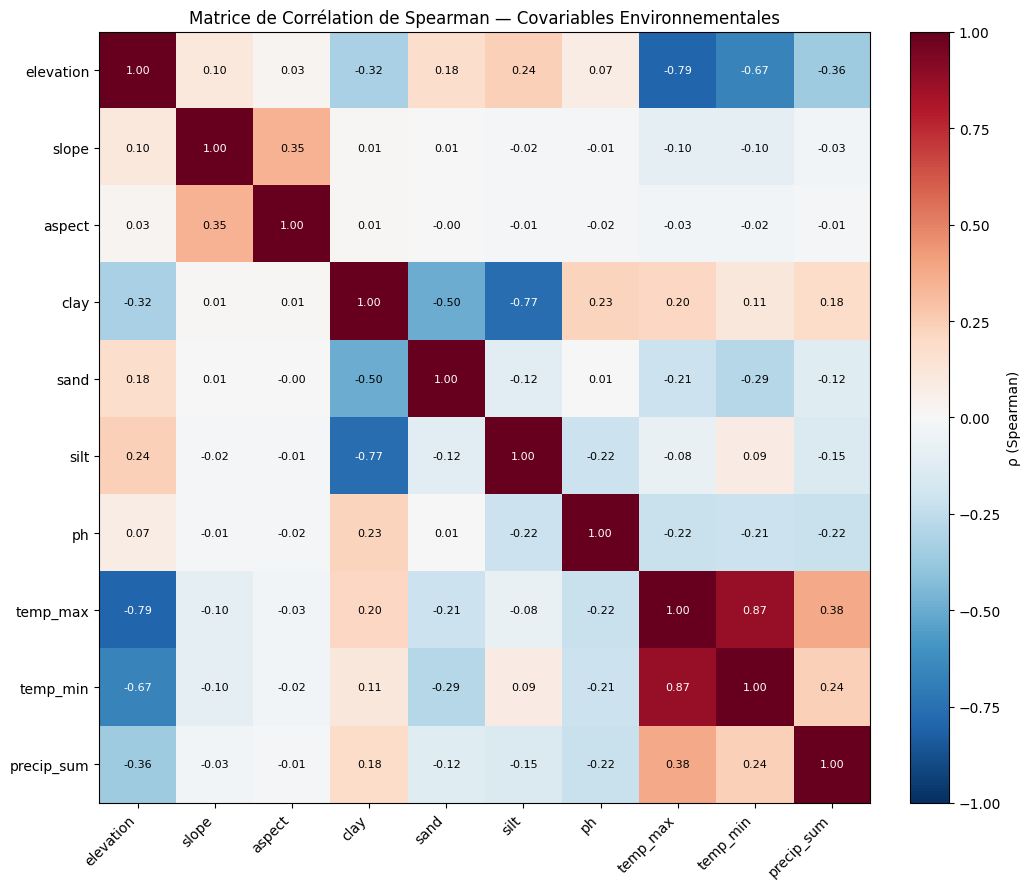

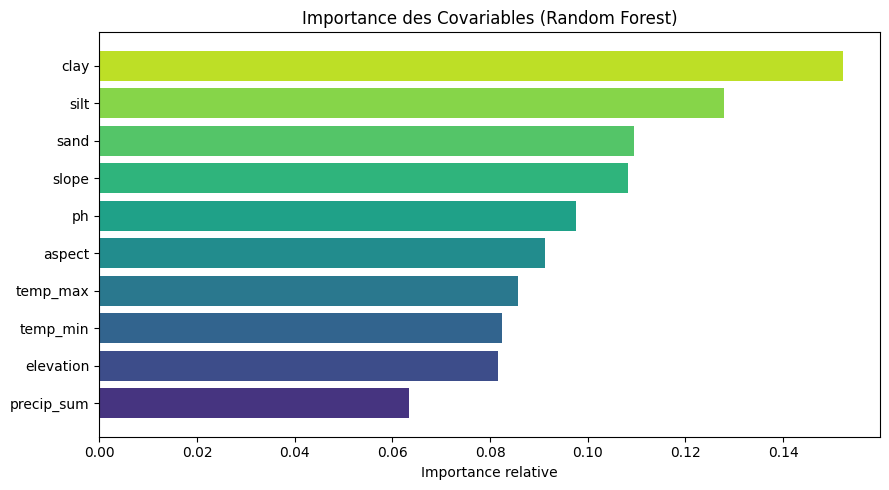

✅ EDA terminée


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

feat_cols = COLS_TOPO + COLS_SOIL + COLS_CLIM
feat_df   = df_cov[feat_cols].copy()

# Matrice Spearman
corr = feat_df.corr(method="spearman", numeric_only=True)
fig1, ax1 = plt.subplots(figsize=(11, 9))
im = ax1.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax1.set_xticks(range(len(corr.columns))); ax1.set_xticklabels(corr.columns, rotation=45, ha="right")
ax1.set_yticks(range(len(corr.columns))); ax1.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label="ρ (Spearman)")
ax1.set_title("Matrice de Corrélation de Spearman — Covariables Environnementales")
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if not np.isnan(v):
            ax1.text(j, i, f"{v:.2f}", ha="center", va="center",
                     fontsize=8, color="white" if abs(v) > 0.5 else "black")
plt.tight_layout()
fig1.savefig(PROJECT_ROOT / "correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

# Random Forest importance
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=int(SEED), n_jobs=-1)
rf.fit(feat_df.values.astype(np.float32), np.asarray(y).reshape(-1))
imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values()
fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.barh(imp.index, imp.values, color=plt.cm.viridis(np.linspace(0.15, 0.9, len(imp))))
ax2.set_xlabel("Importance relative")
ax2.set_title("Importance des Covariables (Random Forest)")
plt.tight_layout()
fig2.savefig(PROJECT_ROOT / "feature_importance_rf.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ EDA terminée")

### Modèle hybride (optionnel) — S2 + 7 covariables statiques

À lancer après l’EDA si vous voulez un entraînement **MCTNet fusion** (temps GPU/CPU). Sinon, passer directement aux cellules d’**ablation**.

In [27]:
import tensorflow as tf
from mctnet_model import build_mctnet

def build_fusion_model(n_timesteps, n_channels, n_classes, n_static):
    """
    Fusion MCTNet + branche MLP statique.
    Utilise directement build_mctnet(n_static_features=n_static)
    avec les bons hyperparamètres (d_model=64, num_heads=4).
    """
    model = build_mctnet(
        n_timesteps=n_timesteps,
        n_channels=n_channels,
        n_classes=n_classes,
        n_static_features=n_static,
        d_model=64,
        num_heads=4,
        ff_dim=128,
        n_stage=3,
        dropout=0.30,
        l2=1e-4,
    )
    return model


# ── Test rapide ───────────────────────────────────────────────
print("Test build_fusion_model...")
from sklearn.preprocessing import StandardScaler

_sc = StandardScaler()
_Xst = _sc.fit_transform(X_static_all_raw[train_idx])[:, :3].astype(np.float32)
_Xsv = _sc.transform(X_static_all_raw[val_idx])[:, :3].astype(np.float32)

_m = build_fusion_model(
    n_timesteps=X_train.shape[1],
    n_channels=X_train.shape[2],
    n_classes=n_classes,
    n_static=3,
)
_m.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=7e-4, weight_decay=5e-4, clipnorm=1.0
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("Fit 2 epochs test...")
_h = _m.fit(
    {"x_s2_clim": X_train, "x_static": _Xst},   # ✅ dict → pas de warning
    y_train,
    validation_data=({"x_s2_clim": X_val, "x_static": _Xsv}, y_val),
    epochs=2, batch_size=64, verbose=1,
)
_acc = _h.history["val_accuracy"][-1]
assert _acc > 0.25, f"❌ Modèle n'apprend pas (val_acc={_acc:.3f})"
print(f"✅ Test OK — val_accuracy epoch 2 = {_acc:.3f}")
del _m, _sc, _Xst, _Xsv, _h

Test build_fusion_model...
Fit 2 epochs test...
Epoch 1/2
239/239 ━━━━━━━━━━━━━━━━━━━━ 51s 79ms/step - accuracy: 0.5592 - loss: 1.3383 - val_accuracy: 0.4182 - val_loss: 2.0223
Epoch 2/2
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.7565 - loss: 0.8305 - val_accuracy: 0.4648 - val_loss: 1.8941
✅ Test OK — val_accuracy epoch 2 = 0.465


✅ Imputation OK — plus aucun NaN
✅ X_clim_train=(15245, 36, 3)
✅ X_static_train=(15245, 7) — NaN=0

🚀 DÉMARRAGE ÉTUDE D'ABLATION (5 configurations)...

  1. S2 original
  n_channels=12, n_static=None
Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 44s 72ms/step - accuracy: 0.5666 - loss: 1.2078 - val_accuracy: 0.5923 - val_loss: 1.1942
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.7404 - loss: 0.8318 - val_accuracy: 0.6899 - val_loss: 0.9303
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.7962 - loss: 0.6895 - val_accuracy: 0.7810 - val_loss: 0.7063
Epoch 4/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.8340 - loss: 0.5950 - val_accuracy: 0.8269 - val_loss: 0.6258
Epoch 5/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.8516 - loss: 0.5353 - val_accuracy: 0.8158 - val_loss: 0.6702
Epoch 6/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.8624 - loss: 0.5023 - val_accuracy: 0.8541 - val_loss: 0.5188
Epoch 7/20
239/239 ━

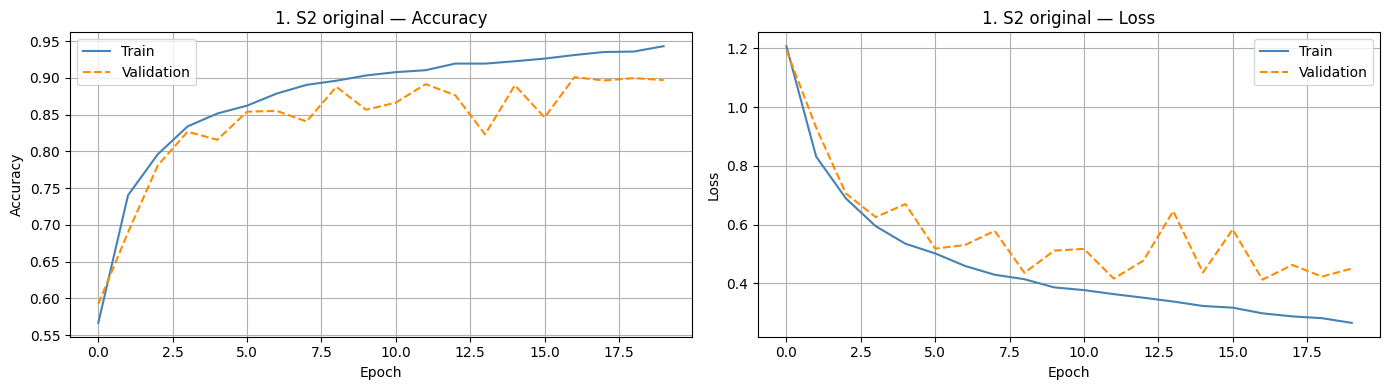

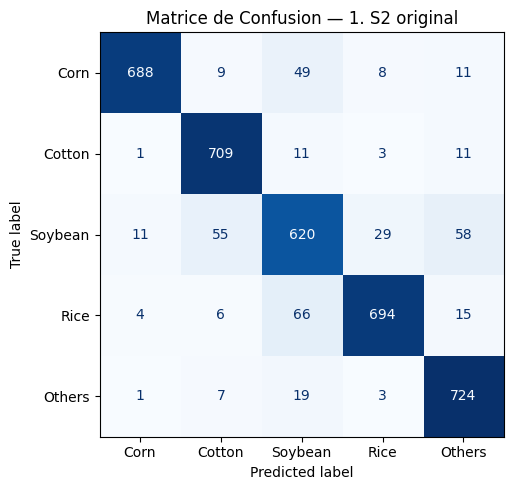


--- Rapport (1. S2 original) ---
              precision    recall  f1-score   support

        Corn       0.98      0.90      0.94       765
      Cotton       0.90      0.96      0.93       735
     Soybean       0.81      0.80      0.81       773
        Rice       0.94      0.88      0.91       785
      Others       0.88      0.96      0.92       754

    accuracy                           0.90      3812
   macro avg       0.90      0.90      0.90      3812
weighted avg       0.90      0.90      0.90      3812

✔️  OA=0.9011

  2. S2 + Climat
  n_channels=15, n_static=None
Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.4898 - loss: 1.3652 - val_accuracy: 0.5703 - val_loss: 1.1971
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.6673 - loss: 1.0079 - val_accuracy: 0.7120 - val_loss: 0.8757
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.7561 - loss: 0.8027 - val_accuracy: 0.7870 - val_loss: 0.7235
Epoch 4/20
239/239 ━━━━━

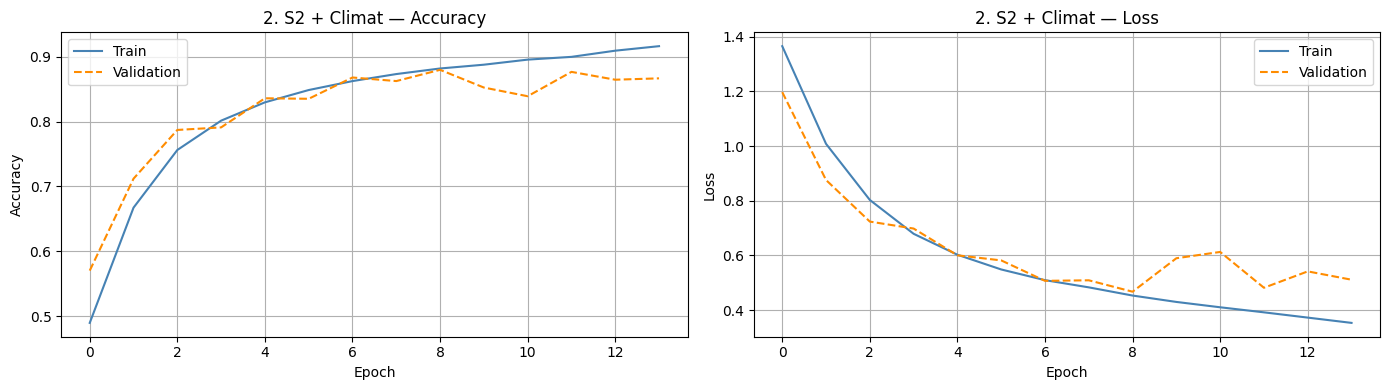

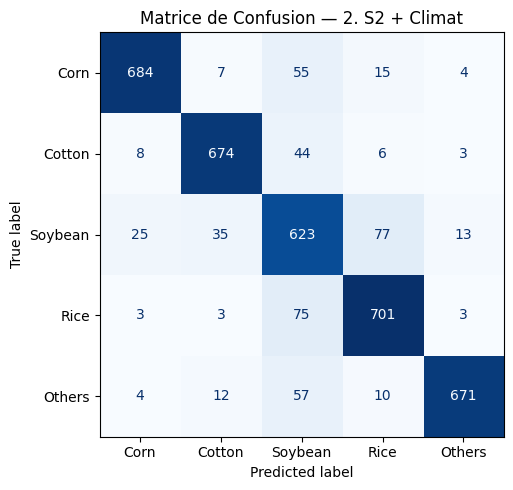


--- Rapport (2. S2 + Climat) ---
              precision    recall  f1-score   support

        Corn       0.94      0.89      0.92       765
      Cotton       0.92      0.92      0.92       735
     Soybean       0.73      0.81      0.77       773
        Rice       0.87      0.89      0.88       785
      Others       0.97      0.89      0.93       754

    accuracy                           0.88      3812
   macro avg       0.89      0.88      0.88      3812
weighted avg       0.88      0.88      0.88      3812

✔️  OA=0.8796

  3. S2 + Sol
  n_channels=12, n_static=4
Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.5276 - loss: 1.3806 - val_accuracy: 0.4441 - val_loss: 1.8679
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.7442 - loss: 0.8637 - val_accuracy: 0.6621 - val_loss: 1.0700
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.8047 - loss: 0.7060 - val_accuracy: 0.6390 - val_loss: 1.0916
Epoch 4/20
239/239 ━━━━━━━━━━━

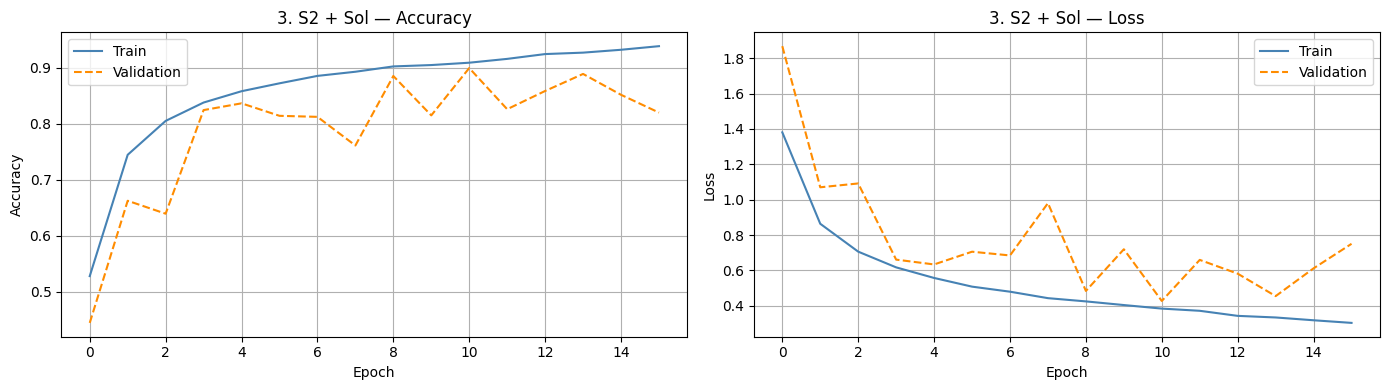

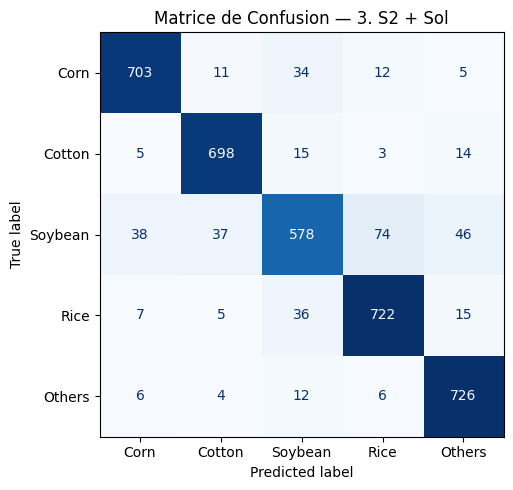


--- Rapport (3. S2 + Sol) ---
              precision    recall  f1-score   support

        Corn       0.93      0.92      0.92       765
      Cotton       0.92      0.95      0.94       735
     Soybean       0.86      0.75      0.80       773
        Rice       0.88      0.92      0.90       785
      Others       0.90      0.96      0.93       754

    accuracy                           0.90      3812
   macro avg       0.90      0.90      0.90      3812
weighted avg       0.90      0.90      0.90      3812

✔️  OA=0.8990

  4. S2 + Topographie
  n_channels=12, n_static=3
Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.5338 - loss: 1.3616 - val_accuracy: 0.4095 - val_loss: 1.4768
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.7456 - loss: 0.8653 - val_accuracy: 0.7316 - val_loss: 0.8755
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.8001 - loss: 0.7184 - val_accuracy: 0.7560 - val_loss: 0.8608
Epoch 4/20
239/239 ━━━━━━

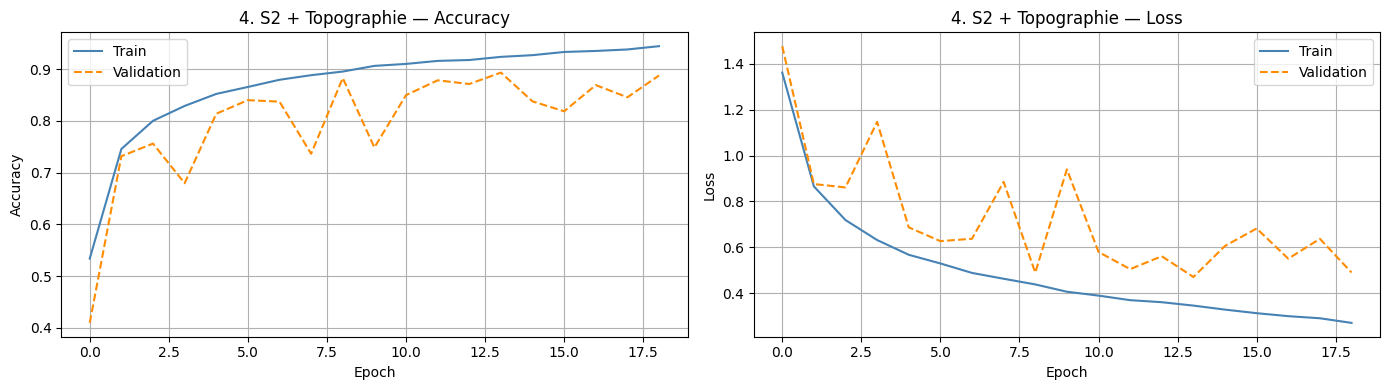

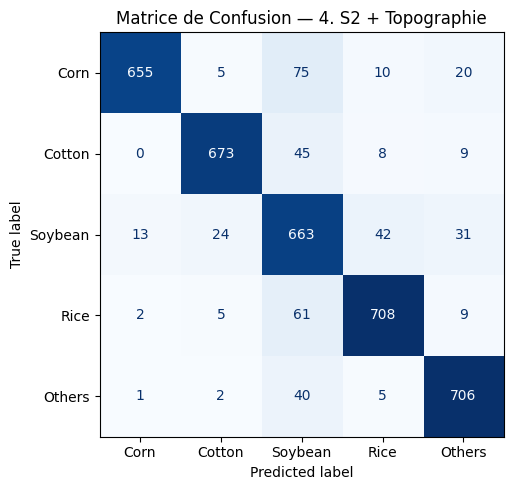


--- Rapport (4. S2 + Topographie) ---
              precision    recall  f1-score   support

        Corn       0.98      0.86      0.91       765
      Cotton       0.95      0.92      0.93       735
     Soybean       0.75      0.86      0.80       773
        Rice       0.92      0.90      0.91       785
      Others       0.91      0.94      0.92       754

    accuracy                           0.89      3812
   macro avg       0.90      0.89      0.90      3812
weighted avg       0.90      0.89      0.89      3812

✔️  OA=0.8932

  5. S2 + Fusion Totale
  n_channels=15, n_static=7
Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.4378 - loss: 1.5480 - val_accuracy: 0.4622 - val_loss: 1.3405
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.6669 - loss: 1.0380 - val_accuracy: 0.7615 - val_loss: 0.8302
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.7443 - loss: 0.8484 - val_accuracy: 0.7141 - val_loss: 0.9344
Epoch 4/20
239/

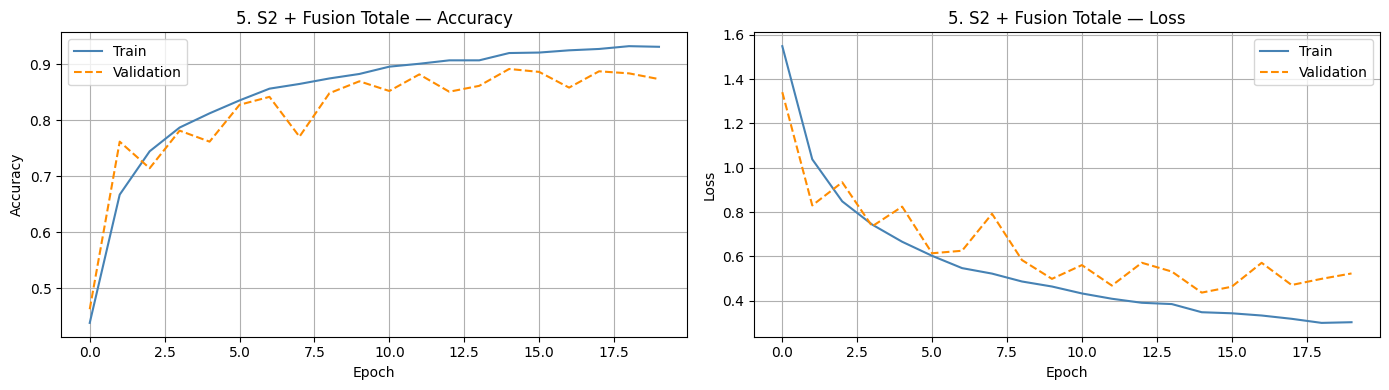

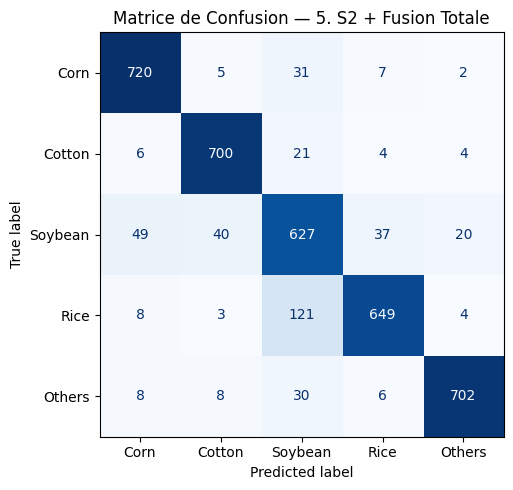


--- Rapport (5. S2 + Fusion Totale) ---
              precision    recall  f1-score   support

        Corn       0.91      0.94      0.93       765
      Cotton       0.93      0.95      0.94       735
     Soybean       0.76      0.81      0.78       773
        Rice       0.92      0.83      0.87       785
      Others       0.96      0.93      0.94       754

    accuracy                           0.89      3812
   macro avg       0.89      0.89      0.89      3812
weighted avg       0.89      0.89      0.89      3812

✔️  OA=0.8914

        RÉSULTATS FINAUX — ÉTUDE D'ABLATION
                       OA (Accuracy)   Kappa  F1 (Macro)
1. S2 original                0.9011  0.8764      0.9014
2. S2 + Climat                0.8796  0.8494      0.8821
3. S2 + Sol                   0.8990  0.8738      0.8980
4. S2 + Topographie           0.8932  0.8665      0.8954
5. S2 + Fusion Totale         0.8914  0.8642      0.8928


In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, f1_score,
    ConfusionMatrixDisplay, classification_report,
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import tensorflow as tf
from mctnet_model import build_mctnet

if "train_idx" not in globals():
    raise RuntimeError("Exécuter d'abord la cellule 1 de la Partie 2.")

T = X_train.shape[1]


imputer = SimpleImputer(strategy="median")
X_static_train_imp = imputer.fit_transform(X_static_all_raw[train_idx])
X_static_val_imp   = imputer.transform(X_static_all_raw[val_idx])

# Vérification
assert np.isnan(X_static_train_imp).sum() == 0, "❌ NaN restants après imputation train"
assert np.isnan(X_static_val_imp).sum()   == 0, "❌ NaN restants après imputation val"
print("✅ Imputation OK — plus aucun NaN")

# Normalisation — fit sur train uniquement
scaler_clim   = StandardScaler()
scaler_static = StandardScaler()

X_clim_train = np.repeat(
    scaler_clim.fit_transform(X_clim_all_raw[train_idx])[:, np.newaxis, :],
    T, axis=1).astype(np.float32)
X_clim_val = np.repeat(
    scaler_clim.transform(X_clim_all_raw[val_idx])[:, np.newaxis, :],
    T, axis=1).astype(np.float32)

X_static_train_scaled = scaler_static.fit_transform(X_static_train_imp).astype(np.float32)
X_static_val_scaled   = scaler_static.transform(X_static_val_imp).astype(np.float32)

# Vérification finale
assert np.isnan(X_static_train_scaled).sum() == 0
assert np.isnan(X_static_val_scaled).sum()   == 0
print(f"✅ X_clim_train={X_clim_train.shape}")
print(f"✅ X_static_train={X_static_train_scaled.shape} — NaN={np.isnan(X_static_train_scaled).sum()}")

# ── Le reste de la cellule 4 reste identique ──────────────────
HPARAMS = dict(d_model=64, num_heads=4, ff_dim=128, n_stage=3, dropout=0.30, l2=1e-4)

configs = [
    {"name": "1. S2 original",        "use_clim": False, "use_static": None},
    {"name": "2. S2 + Climat",         "use_clim": True,  "use_static": None},
    {"name": "3. S2 + Sol",            "use_clim": False, "use_static": [3, 4, 5, 6]},
    {"name": "4. S2 + Topographie",    "use_clim": False, "use_static": [0, 1, 2]},
    {"name": "5. S2 + Fusion Totale",  "use_clim": True,  "use_static": [0, 1, 2, 3, 4, 5, 6]},
]

real_results = {}
print("\n🚀 DÉMARRAGE ÉTUDE D'ABLATION (5 configurations)...")

for config in configs:
    print(f"\n{'='*55}")
    print(f"  {config['name']}")
    print(f"{'='*55}")

    X_tr = X_train.copy()
    X_vl = X_val.copy()
    if config["use_clim"]:
        X_tr = np.concatenate([X_tr, X_clim_train], axis=-1)
        X_vl = np.concatenate([X_vl, X_clim_val],   axis=-1)

    n_static = None
    if config["use_static"] is not None:
        idx_s    = config["use_static"]
        n_static = len(idx_s)
        train_in = {
            "x_s2_clim": X_tr,
            "x_static":  X_static_train_scaled[:, idx_s],
        }
        val_in = {
            "x_s2_clim": X_vl,
            "x_static":  X_static_val_scaled[:, idx_s],
        }
    else:
        train_in = {"x_s2_clim": X_tr}
        val_in   = {"x_s2_clim": X_vl}

    print(f"  n_channels={X_tr.shape[2]}, n_static={n_static}")

    model = build_mctnet(
        n_timesteps=X_train.shape[1],
        n_channels=X_tr.shape[2],
        n_classes=n_classes,
        n_static_features=n_static,
        **HPARAMS,
    )
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=7e-4, weight_decay=5e-4, clipnorm=1.0,
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    history = model.fit(
        train_in, y_train,
        validation_data=(val_in, y_val),
        epochs=20, batch_size=64, verbose=1,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_accuracy", patience=5,
                restore_best_weights=True, verbose=1,
            )
        ],
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history["accuracy"],     label="Train",      color="steelblue")
    ax1.plot(history.history["val_accuracy"], label="Validation", color="darkorange", ls="--")
    ax1.set_title(f"{config['name']} — Accuracy")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy"); ax1.legend(); ax1.grid(True)
    ax2.plot(history.history["loss"],     label="Train",      color="steelblue")
    ax2.plot(history.history["val_loss"], label="Validation", color="darkorange", ls="--")
    ax2.set_title(f"{config['name']} — Loss")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss"); ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()

    y_pred = np.argmax(model.predict(val_in, verbose=0), axis=-1)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred, display_labels=PAPER_LABELS,
        cmap="Blues", ax=ax, colorbar=False,
    )
    ax.set_title(f"Matrice de Confusion — {config['name']}")
    plt.tight_layout(); plt.show()

    print(f"\n--- Rapport ({config['name']}) ---")
    print(classification_report(y_val, y_pred, target_names=PAPER_LABELS))

    real_results[config["name"]] = {
        "OA (Accuracy)": accuracy_score(y_val, y_pred),
        "Kappa":         cohen_kappa_score(y_val, y_pred),
        "F1 (Macro)":    f1_score(y_val, y_pred, average="macro"),
    }
    print(f"✔️  OA={real_results[config['name']]['OA (Accuracy)']:.4f}")

df_ablation = pd.DataFrame(real_results).T
print("\n" + "="*60)
print("        RÉSULTATS FINAUX — ÉTUDE D'ABLATION")
print("="*60)
print(df_ablation.round(4))